# Study Question:

This notebook will try to begin to spec mininmum requirements for v0.1 of design

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))


In [2]:
import numpy as np
from simulation_modeling import v0_model
from simulation_modeling.passive_joint_models import (PassiveFingerParameters,
    PassiveJointParameters,
    passive_required_torque_vector,
)

finger_params = PassiveFingerParameters(
    mcp=PassiveJointParameters("MCP", 0.0, 0.08),
    pip=PassiveJointParameters("PIP", 0.0, 0.045),
    dip=PassiveJointParameters("DIP", 0.0, 0.025),
)

q_sweep = v0_model.coordinated_flexion_sweep()
tau_required = np.array([passive_required_torque_vector(q, finger_params) for q in q_sweep])
# print(f"{tau_required = }")

for q, tau in zip(q_sweep[:5], tau_required[:5]):
    print("q deg:", np.rad2deg(q), "tau Nm:", tau)


q deg: [0. 0. 0.] tau Nm: [0. 0. 0.]
q deg: [-0.81632653 -1.2244898  -0.97959184] tau Nm: [-0.00113981 -0.00096171 -0.00042743]
q deg: [-1.63265306 -2.44897959 -1.95918367] tau Nm: [-0.00227961 -0.00192342 -0.00085486]
q deg: [-2.44897959 -3.67346939 -2.93877551] tau Nm: [-0.00341942 -0.00288514 -0.00128228]
q deg: [-3.26530612 -4.89795918 -3.91836735] tau Nm: [-0.00455923 -0.00384685 -0.00170971]


In [3]:
geom = v0_model.FingerGeometry(41.0, 26.0, 20.0)
h = 5.0   # channel offset in the 2D flexion plane
u = 5.0   # element location along each phalanx
x_entry = -20.0
# path = v0_model.RoutingPath(
#         "flexion_path",
#         (
#             v0_model.RoutingElement("flex_entry", "world", "entry", np.array([x_entry, -h], dtype=float)),
#             v0_model.RoutingElement("flex_prox", "proximal", "guide", np.array([u, -h], dtype=float)),
#             v0_model.RoutingElement("flex_mid", "middle", "guide", np.array([u, -h], dtype=float)),
#             v0_model.RoutingElement("flex_dist", "distal", "anchor", np.array([u, -h], dtype=float)),
#         ),
#     )

path = v0_model.RoutingPath(
        "extension_path",
        (
            v0_model.RoutingElement("ext_entry", "world", "entry", np.array([x_entry, -h], dtype=float)),
            v0_model.RoutingElement("ext_prox", "proximal", "guide", np.array([u, -h], dtype=float)),
            v0_model.RoutingElement("ext_mid", "middle", "guide", np.array([u, -h], dtype=float)),
            v0_model.RoutingElement("ext_dist", "distal", "anchor", np.array([u, -h], dtype=float)),
        ),
    )

tau_tendon_per_newton_nmm = np.array([
    v0_model.tendon_torque(path, geom, tuple(q), T=1.0)
    for q in q_sweep
])

tau_tendon_per_newton_nm = 1e-3 * tau_tendon_per_newton_nmm




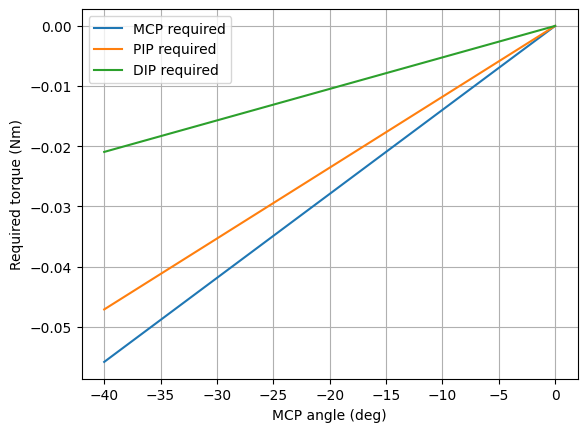

In [4]:
# import plotly.graph_objects as go

# fig = go.Figure()

# for tau_req in tau_required:
#     # label = f"3"
#     fig.add_trace(
#         go.Scatter(
#             x=q_sweep,
#             y=tau_required,
#             mode="lines",
#             name='label',
#             hovertemplate="theta_target = %{x:.1f} deg<br>tau_required = %{y:.3f} N·m<br>%{fullData.name}<extra></extra>",
#         )
#     )


import matplotlib.pyplot as plt
import numpy as np

mcp_deg = np.rad2deg(q_sweep[:, 0])

plt.figure()
plt.plot(mcp_deg, tau_required[:, 0], label="MCP required")
plt.plot(mcp_deg, tau_required[:, 1], label="PIP required")
plt.plot(mcp_deg, tau_required[:, 2], label="DIP required")
plt.xlabel("MCP angle (deg)")
plt.ylabel("Required torque (Nm)")
plt.legend()
plt.grid(True)
plt.show()


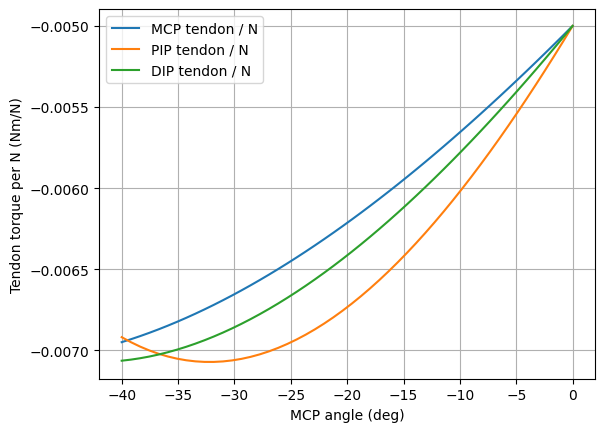

In [5]:
plt.figure()
plt.plot(mcp_deg, tau_tendon_per_newton_nm[:, 0], label="MCP tendon / N")
plt.plot(mcp_deg, tau_tendon_per_newton_nm[:, 1], label="PIP tendon / N")
plt.plot(mcp_deg, tau_tendon_per_newton_nm[:, 2], label="DIP tendon / N")
plt.xlabel("MCP angle (deg)")
plt.ylabel("Tendon torque per N (Nm/N)")
plt.legend()
plt.grid(True)
plt.show()


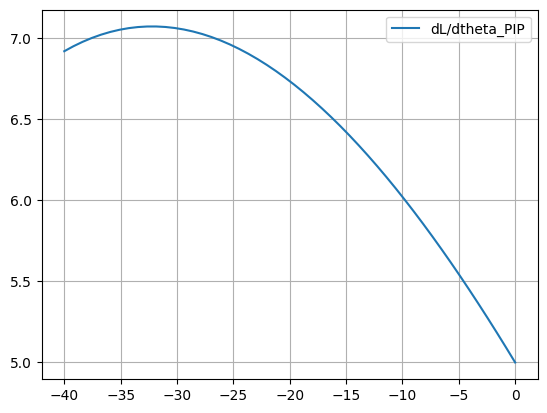

In [6]:
grads = np.array([
    v0_model.tendon_gradient(geom, path, tuple(q))
    for q in q_sweep
])

plt.plot(mcp_deg, grads[:, 1], label="dL/dtheta_PIP")
plt.legend()
plt.grid(True)


In [7]:

'''
==========
Solvants
==========
tendon excursion
required tension range
max actuator stroke
dL/dq smoothness
MCP/PIP/DIP torque distribution
sensitivity to finger size
guide count / complexity
palmar clearance proxy


'''


mcp_target_motion = np.deg2rad(np.arange(-75, 0, 10))
pip_target_motion = np.deg2rad(np.arange(-90, 0, 10))
dip_target_motion = np.deg2rad(np.arange(-60, 0, 10))

idx_L_prox = 50 # mm
idx_L_mid = 30 # mm
idx_L_dist = 22 # mm

idx_D_prox = 20 # mm
idx_D_mid = 16 # mm
idx_D_dist = 13 # mm

neutral_pose = np.array([0, 0, 0])
geom = v0_model.FingerGeometry(idx_L_prox, idx_L_mid, idx_L_dist)

# there is nowhere for me to introduce link section? should that be implemented?
# is joint coupling introduced in the code anywhere

phi_mcp = v0_model.forward_kinematics(geom=geom, joint_angles=(mcp_target_motion))
phi_pip = v0_model.forward_kinematics(geom=geom, q=pip_target_motion)
phi_dip = v0_model.forward_kinematics(geom=geom, q=dip_target_motion)


# how to make routing path_flex/extend parametric/sweep

x_entry = x_entry
y_extry = 0 

ring_count_prox = np.array([0, 1, 2])
ring_count_mid = np.array([0, 1, 2])
ring_count_dist = np.array([0, 1])

# always will have distal anchor

u_ring_prox = np.arange(0, 0.9, 0.1) * idx_L_prox
u_ring_mid = np.arange(0, 0.9, 0.1) * idx_L_mid
u_ring_dist = np.arange(0, 0.9, 0.1) * idx_L_dist

# what is the more programic way of doing this?


clearance_skin = 1.5 # mm
ring_ID_prox = idx_D_prox + 2 * clearance_skin
ring_ID_mid = idx_D_mid + 2 * clearance_skin
ring_ID_dist = idx_D_dist + 2 * clearance_skin



v_ring_prox = np.arange(-.2, 0.2, 0.01) * idx_D_prox + clearance_skin
v_ring_mid = np.arange(-.2, 0.2, 0.01) * idx_D_mid + clearance_skin
v_ring_dist = np.arange(-.2, 0.2, 0.01) * idx_D_dist + clearance_skin


'''
still need to add tendon slots/holes
ring wall thickness
thimble anchor
tendon diameter
initial slack

then sweep, should I use a library for that? implement it myself?
I already have the torque laws, what else do i need?
'''








TypeError: forward_kinematics() got an unexpected keyword argument 'q'

In [ ]:
'''
============
Design Table
============

Will compute based on sweep best design, output to a .csv
'''

In [ ]:
'''
============
Visualizer
============

Based on top 3-5 designs will create a 2d sketch for me to implement in fusoin

'''

